### MINERvA ME one-step reweight for GENIE v3 AR23: SuSAv2 2p2h to new Valencia exclusive 

In [3]:
import sys
sys.path.append('/exp/minerva/app/users/zihaolin/REWEIGHTworkdir/')
from BDTReweight.nuisance_flat_tree import NuisanceFlatTree
from BDTReweight.analysis import transform_momentum_to_reaction_frame, draw_source_target_distributions_and_ratio, create_dataframe_from_nuisance
from BDTReweight.reweighter import Reweighter
from BDTReweight.utilities import particle_mass_lookup
from BDTReweight.utilities import particle_variable_to_latex, diff_xsec_latex_wrt_variable
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


from BDTReweight.json_reweighter import (
    JSONReweighter,
    export_reweighter_json,
)

In [4]:
# dict object to store data frames
oldInclusive = {}
newExclusive = {}
size = 100000
geniev3_seed = 515
# change this
exclusive_size_pp = 20000
exclusive_size_pn = 20000


Prepare new exclusive pp and pn:

In [5]:
# prepare new exclusive pp:
category = 'pp'


# new Valencia inclusive, exclusive:
variables = {'muon_E':'leading_muon_E', 'muon_Px':'leading_muon_px', 'muon_Py':'leading_muon_py', 'muon_Pz':'leading_muon_pz', 'muon_P':'leading_muon_P', 
    'neutrino_E':'init_neutrino_E', 'neutrino_Px':'init_neutrino_px', 'neutrino_Py':'init_neutrino_py',
    'neutrino_Pz':'init_neutrino_pz', 'neutrino_P':'init_neutrino_P',
    'nucleon1_out_E':'leading_proton_E', 'nucleon1_out_Px':'leading_proton_px', 'nucleon1_out_Py':'leading_proton_py', 
    'nucleon1_out_Pz':'leading_proton_pz','nucleon1_out_P':'leading_proton_P',
    'nucleon2_out_E':'subleading_proton_E', 'nucleon2_out_Px':'subleading_proton_px', 'nucleon2_out_Py':'subleading_proton_py', 
    'nucleon2_out_Pz':'subleading_proton_pz','nucleon2_out_P':'subleading_proton_P', 
    'Q_E':'qtransfer_E', 'Q_Px':'qtransfer_px', 'Q_Py':'qtransfer_py', 'Q_Pz':'qtransfer_pz', 'Q_P':'qtransfer_P', 'weight_pp':'weight'}

data_folder = '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/PreFsi'



newExclusive[category] = uproot.open(f'{data_folder}/KinematicVariables_Enu=_Minerva__Exclusive.root')['T'].arrays(library='pd',entry_start=0, entry_stop=exclusive_size_pp)[variables.keys()]



# drop Enu > 20 GeV for now
newExclusive[category] = newExclusive[category].loc[newExclusive[category]['neutrino_E'] <= 20000.0]


# relabel nucleon 1 and 2 to ensure nucleon1_out_E >= nucleon2_out_E 
mask = newExclusive[category]['nucleon1_out_E'] < newExclusive[category]['nucleon2_out_E']
newExclusive[category].loc[mask, ['nucleon1_out_E', 'nucleon2_out_E']] = newExclusive[category].loc[mask, ['nucleon2_out_E', 'nucleon1_out_E']].to_numpy()
newExclusive[category].loc[mask, ['nucleon1_out_P', 'nucleon2_out_P']] = newExclusive[category].loc[mask, ['nucleon2_out_P', 'nucleon1_out_P']].to_numpy()
newExclusive[category].loc[mask, ['nucleon1_out_Px', 'nucleon2_out_Px']] = newExclusive[category].loc[mask, ['nucleon2_out_Px', 'nucleon1_out_Px']].to_numpy()
newExclusive[category].loc[mask, ['nucleon1_out_Py', 'nucleon2_out_Py']] = newExclusive[category].loc[mask, ['nucleon2_out_Py', 'nucleon1_out_Py']].to_numpy()
newExclusive[category].loc[mask, ['nucleon1_out_Pz', 'nucleon2_out_Pz']] = newExclusive[category].loc[mask, ['nucleon2_out_Pz', 'nucleon1_out_Pz']].to_numpy()




newExclusive[category] = newExclusive[category].rename(columns = variables)

newExclusive[category] = newExclusive[category].loc[newExclusive[category]['weight']>=0]

newExclusive[category] = transform_momentum_to_reaction_frame(newExclusive[category], selector_lepton='leading_muon',particle_names=['leading_proton','subleading_proton','qtransfer'])
# for df in [source_train, source_test, target_train, target_test]:
for df in [newExclusive[category]]:
    df['q0'] = df['qtransfer_E']
    df['q3'] = df['qtransfer_P']
    df['Q2'] = df['q3']**2 - df['q0']**2



In [6]:
# prepare new exclusive pn:
category = 'pn'
# new Valencia inclusive, exclusive:
variables = {
    'muon_E':'leading_muon_E', 'muon_Px':'leading_muon_px', 'muon_Py':'leading_muon_py', 'muon_Pz':'leading_muon_pz', 'muon_P':'leading_muon_P', 
    'neutrino_E':'init_neutrino_E', 'neutrino_Px':'init_neutrino_px', 'neutrino_Py':'init_neutrino_py', 'neutrino_Pz':'init_neutrino_pz', 'neutrino_P':'init_neutrino_P',
    'nucleon1_out_E':'leading_proton_E', 'nucleon1_out_Px':'leading_proton_px', 'nucleon1_out_Py':'leading_proton_py', 'nucleon1_out_Pz':'leading_proton_pz','nucleon1_out_P':'leading_proton_P',
    'nucleon2_out_E':'leading_neutron_E', 'nucleon2_out_Px':'leading_neutron_px', 'nucleon2_out_Py':'leading_neutron_py', 'nucleon2_out_Pz':'leading_neutron_pz','nucleon2_out_P':'leading_neutron_P', 
    'Q_E':'qtransfer_E', 'Q_Px':'qtransfer_px', 'Q_Py':'qtransfer_py', 'Q_Pz':'qtransfer_pz', 'Q_P':'qtransfer_P'}

data_folder = '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/PreFsi'


newExclusive[category] = uproot.open(f'{data_folder}/KinematicVariables_Enu=_Minerva__Exclusive.root')['T'].arrays(library='pd',entry_start=exclusive_size_pp, entry_stop=exclusive_size_pp+exclusive_size_pn)[variables.keys()]
newExclusive[category] = newExclusive[category].rename(columns = variables)

# weight = weight_pn + weight_np
df_weight = uproot.open(f'{data_folder}/KinematicVariables_Enu=_Minerva__Exclusive.root')['T'].arrays(library='pd',entry_start=exclusive_size_pp, entry_stop=exclusive_size_pp+exclusive_size_pn)[['weight_pn','weight_np']]
newExclusive[category]['weight'] = df_weight['weight_pn'] + df_weight['weight_np']


newExclusive[category] = newExclusive[category].loc[newExclusive[category]['weight']>=0]

# drop Enu > 10 GeV for now
newExclusive[category] = newExclusive[category].loc[newExclusive[category]['init_neutrino_E'] <= 20000.0]


newExclusive[category] = transform_momentum_to_reaction_frame(newExclusive[category], selector_lepton='leading_muon',particle_names=['leading_proton','leading_neutron','qtransfer'])
# for df in [source_train, source_test, target_train, target_test]:
for df in [newExclusive[category]]:
    df['q0'] = df['qtransfer_E']
    df['q3'] = df['qtransfer_P']
    df['Q2'] = df['q3']**2 - df['q0']**2




In [7]:
# convert new exclusive from MeV to GeV
for category in ['pp', 'pn']:
    for col in newExclusive[category].columns:
        if col == 'Q2':
            newExclusive[category][col] = newExclusive[category][col] / 1000000
        elif col == 'weight':
            continue
        else:
            newExclusive[category][col] = newExclusive[category][col] / 1000

Prepare old pp and pn at vertex:

In [8]:
# Feb23: This file has FSI: use vertex info. old Valencia inclusive as implemented in NEUT: (total entries: 10000000)
tree_genie = NuisanceFlatTree(
    # '/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIEv3_AR23_MINERvA_ME_FHC_numu_C12_501_NUISFLAT.root',
    f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIEv3_AR23_MINERvA_ME_FHC_numu_CH_{geniev3_seed}_NUISFLAT.root',
    # '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors.root',
    # '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/NEUT_output_files/NEUT:OldValencia_2p2h_minervaFlux_10k.root.GenericVectors.root',
    entry_start = 0, entry_stop = size)

# drop Enu > 10 GeV events for now
mask_2p2h = (tree_genie._flattree_vars['Enu_true'] <= 20.0) & (tree_genie._flattree_vars['Mode'] == 2) & (tree_genie._flattree_vars['nvertp'] == 6)
entries_2p2h = np.arange(0, len(mask_2p2h), 1)[mask_2p2h]
tree_genie.update_tree_with_mask(mask_2p2h)

# create df
oldInclusive['pp'] = pd.DataFrame()
oldInclusive['pn'] = pd.DataFrame()
# oldInclusive['np'] = pd.DataFrame()


# vertp_pdg = tree_genie._flattree_vars['pdg_vert'][:,4:]
# vertp_E = tree_genie._flattree_vars['E_vert'][:,4:]
# vertp_px = tree_genie._flattree_vars['px_vert'][:,4:]
# vertp_py = tree_genie._flattree_vars['py_vert'][:,4:]
# vertp_pz = tree_genie._flattree_vars['pz_vert'][:,4:]
vertp_pdg = tree_genie._flattree_vars['pdg_vert'][:,3:5]
vertp_E = tree_genie._flattree_vars['E_vert'][:,3:5]
vertp_px = tree_genie._flattree_vars['px_vert'][:,3:5]
vertp_py = tree_genie._flattree_vars['py_vert'][:,3:5]
vertp_pz = tree_genie._flattree_vars['pz_vert'][:,3:5]



vertp_mass = ak.where(vertp_pdg == 2212, particle_mass_lookup('proton'),
    ak.where(vertp_pdg == 2112, particle_mass_lookup('neutron'), -999.0)
)
vertp_KE = vertp_E - vertp_mass
order = ak.argsort(vertp_KE, axis=1, ascending=False)
primary_pdg = vertp_pdg[order][:,0]
spectator_pdg = vertp_pdg[order][:,1]

maskvertp = {}
maskvertp['pp'] = (primary_pdg == 2212) & (spectator_pdg == 2212)
maskvertp['pn'] = ~ ((primary_pdg == 2212) & (spectator_pdg == 2212))
# maskvertp['np'] = primary_pdg == 2112

# keep track of entries:
entrie_pp = entries_2p2h[maskvertp['pp']]
entrie_pn = entries_2p2h[maskvertp['pn']]
print(len(entrie_pp), len(entrie_pn), len(entries_2p2h))

# get muon kinematics, momentum transfer, and Enu first:
# for category in ['pp', 'pn', 'np']:
for category in ['pp', 'pn']:
    oldInclusive[category]['leading_muon_px'] = tree_genie._flattree_vars['px_vert'][:,5][maskvertp[category]]
    oldInclusive[category]['leading_muon_py'] = tree_genie._flattree_vars['py_vert'][:,5][maskvertp[category]]
    oldInclusive[category]['leading_muon_pz'] = tree_genie._flattree_vars['pz_vert'][:,5][maskvertp[category]]
    # oldInclusive[category]['leading_muon_px'] = tree_genie._flattree_vars['px_vert'][:,3][maskvertp[category]]
    # oldInclusive[category]['leading_muon_py'] = tree_genie._flattree_vars['py_vert'][:,3][maskvertp[category]]
    # oldInclusive[category]['leading_muon_pz'] = tree_genie._flattree_vars['pz_vert'][:,3][maskvertp[category]]
    oldInclusive[category]['init_neutrino_E'] = tree_genie._flattree_vars['Enu_true'][maskvertp[category]]
    oldInclusive[category]['q0'] = tree_genie._flattree_vars['q0'][maskvertp[category]]
    oldInclusive[category]['q3'] = tree_genie._flattree_vars['q3'][maskvertp[category]]
    oldInclusive[category]['Q2'] = tree_genie._flattree_vars['Q2'][maskvertp[category]]



# pp channel proton kinematics:
category = 'pp'
leading_i = ak.argmax(vertp_KE, axis=1, keepdims=True)
subleading_i = ak.argmin(vertp_KE, axis=1, keepdims=True)
oldInclusive[category]['leading_proton_px'] = vertp_px[leading_i][maskvertp[category]]
oldInclusive[category]['leading_proton_py'] = vertp_py[leading_i][maskvertp[category]]
oldInclusive[category]['leading_proton_pz'] = vertp_pz[leading_i][maskvertp[category]]
oldInclusive[category]['subleading_proton_px'] = vertp_px[subleading_i][maskvertp[category]]
oldInclusive[category]['subleading_proton_py'] = vertp_py[subleading_i][maskvertp[category]]
oldInclusive[category]['subleading_proton_pz'] = vertp_pz[subleading_i][maskvertp[category]]
oldInclusive[category] = transform_momentum_to_reaction_frame(oldInclusive[category],
    selector_lepton='leading_muon', particle_names=['leading_proton', 'subleading_proton'])

# pn channel
category = 'pn'
oldInclusive[category]['leading_proton_px'] = ak.firsts(vertp_px[vertp_pdg == 2212])[maskvertp['pn']]
oldInclusive[category]['leading_proton_py'] = ak.firsts(vertp_py[vertp_pdg == 2212])[maskvertp['pn']]
oldInclusive[category]['leading_proton_pz'] = ak.firsts(vertp_pz[vertp_pdg == 2212])[maskvertp['pn']]
oldInclusive[category]['leading_neutron_px'] = ak.firsts(vertp_px[vertp_pdg == 2112])[maskvertp['pn']]
oldInclusive[category]['leading_neutron_py'] = ak.firsts(vertp_py[vertp_pdg == 2112])[maskvertp['pn']]
oldInclusive[category]['leading_neutron_pz'] = ak.firsts(vertp_pz[vertp_pdg == 2112])[maskvertp['pn']]
oldInclusive[category] = transform_momentum_to_reaction_frame(oldInclusive[category],
    selector_lepton='leading_muon', particle_names=['leading_proton', 'leading_neutron'])

# keep track of entries:
oldInclusive['pp']['entry'] = entrie_pp
oldInclusive['pn']['entry'] = entrie_pn



2175 626 2801


GENIE doesn't have 3p3h in Mode 2, assign weight0 = 1.

In [9]:
# Scale up 2p2h strength by 3p3h contribution, pp and pn:
# pp:
category = 'pp'
oldInclusive[category]['weight0'] = np.ones(len(oldInclusive[category])) * np.sum(newExclusive[category]['weight'])/len(oldInclusive[category])


# pn:
category='pn'
oldInclusive[category]['weight0'] = np.ones(len(oldInclusive[category])) * np.sum(newExclusive[category]['weight'])/len(oldInclusive[category])


Reweight and plot pp, preFSI:

In [10]:
# prepare dataframes and reweight training

category = 'pp'


# reweight to new inclusive first:
# train reweighter
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    # 'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    # 'init_neutrino_E'
]

reweighter = Reweighter(n_estimators=200, learning_rate=0.1, max_depth=4, min_samples_leaf=20, gb_args={'subsample': 1.0})
reweighter.fit(oldInclusive[category][reweight_variables], newExclusive[category][reweight_variables],
            original_weight=oldInclusive[category]['weight0'],
            target_weight=newExclusive[category]['weight']
)
# reweighter.save_to_pickle(f'/exp/minerva/data/users/zihaolin/BDTReweighters/saved_reweighters_pickle/Valencia/reweighter_Minerva_flux_Valencia_2p2h_newInclusive_to_newExclusive_{category}.pkl')
# # load from saved
# reweighter = Reweighter.load_from_pickle(f'/exp/minerva/data/users/zihaolin/BDTReweighters/saved_reweighters_pickle/Valencia/reweighter_Minerva_flux_Valencia_2p2h_newInclusive_to_newExclusive_{category}.pkl')


,n_estimators,200
,learning_rate,0.1
,max_depth,4
,min_samples_leaf,20
,loss_regularization,5
,gb_args,{'subsample': 1.0}


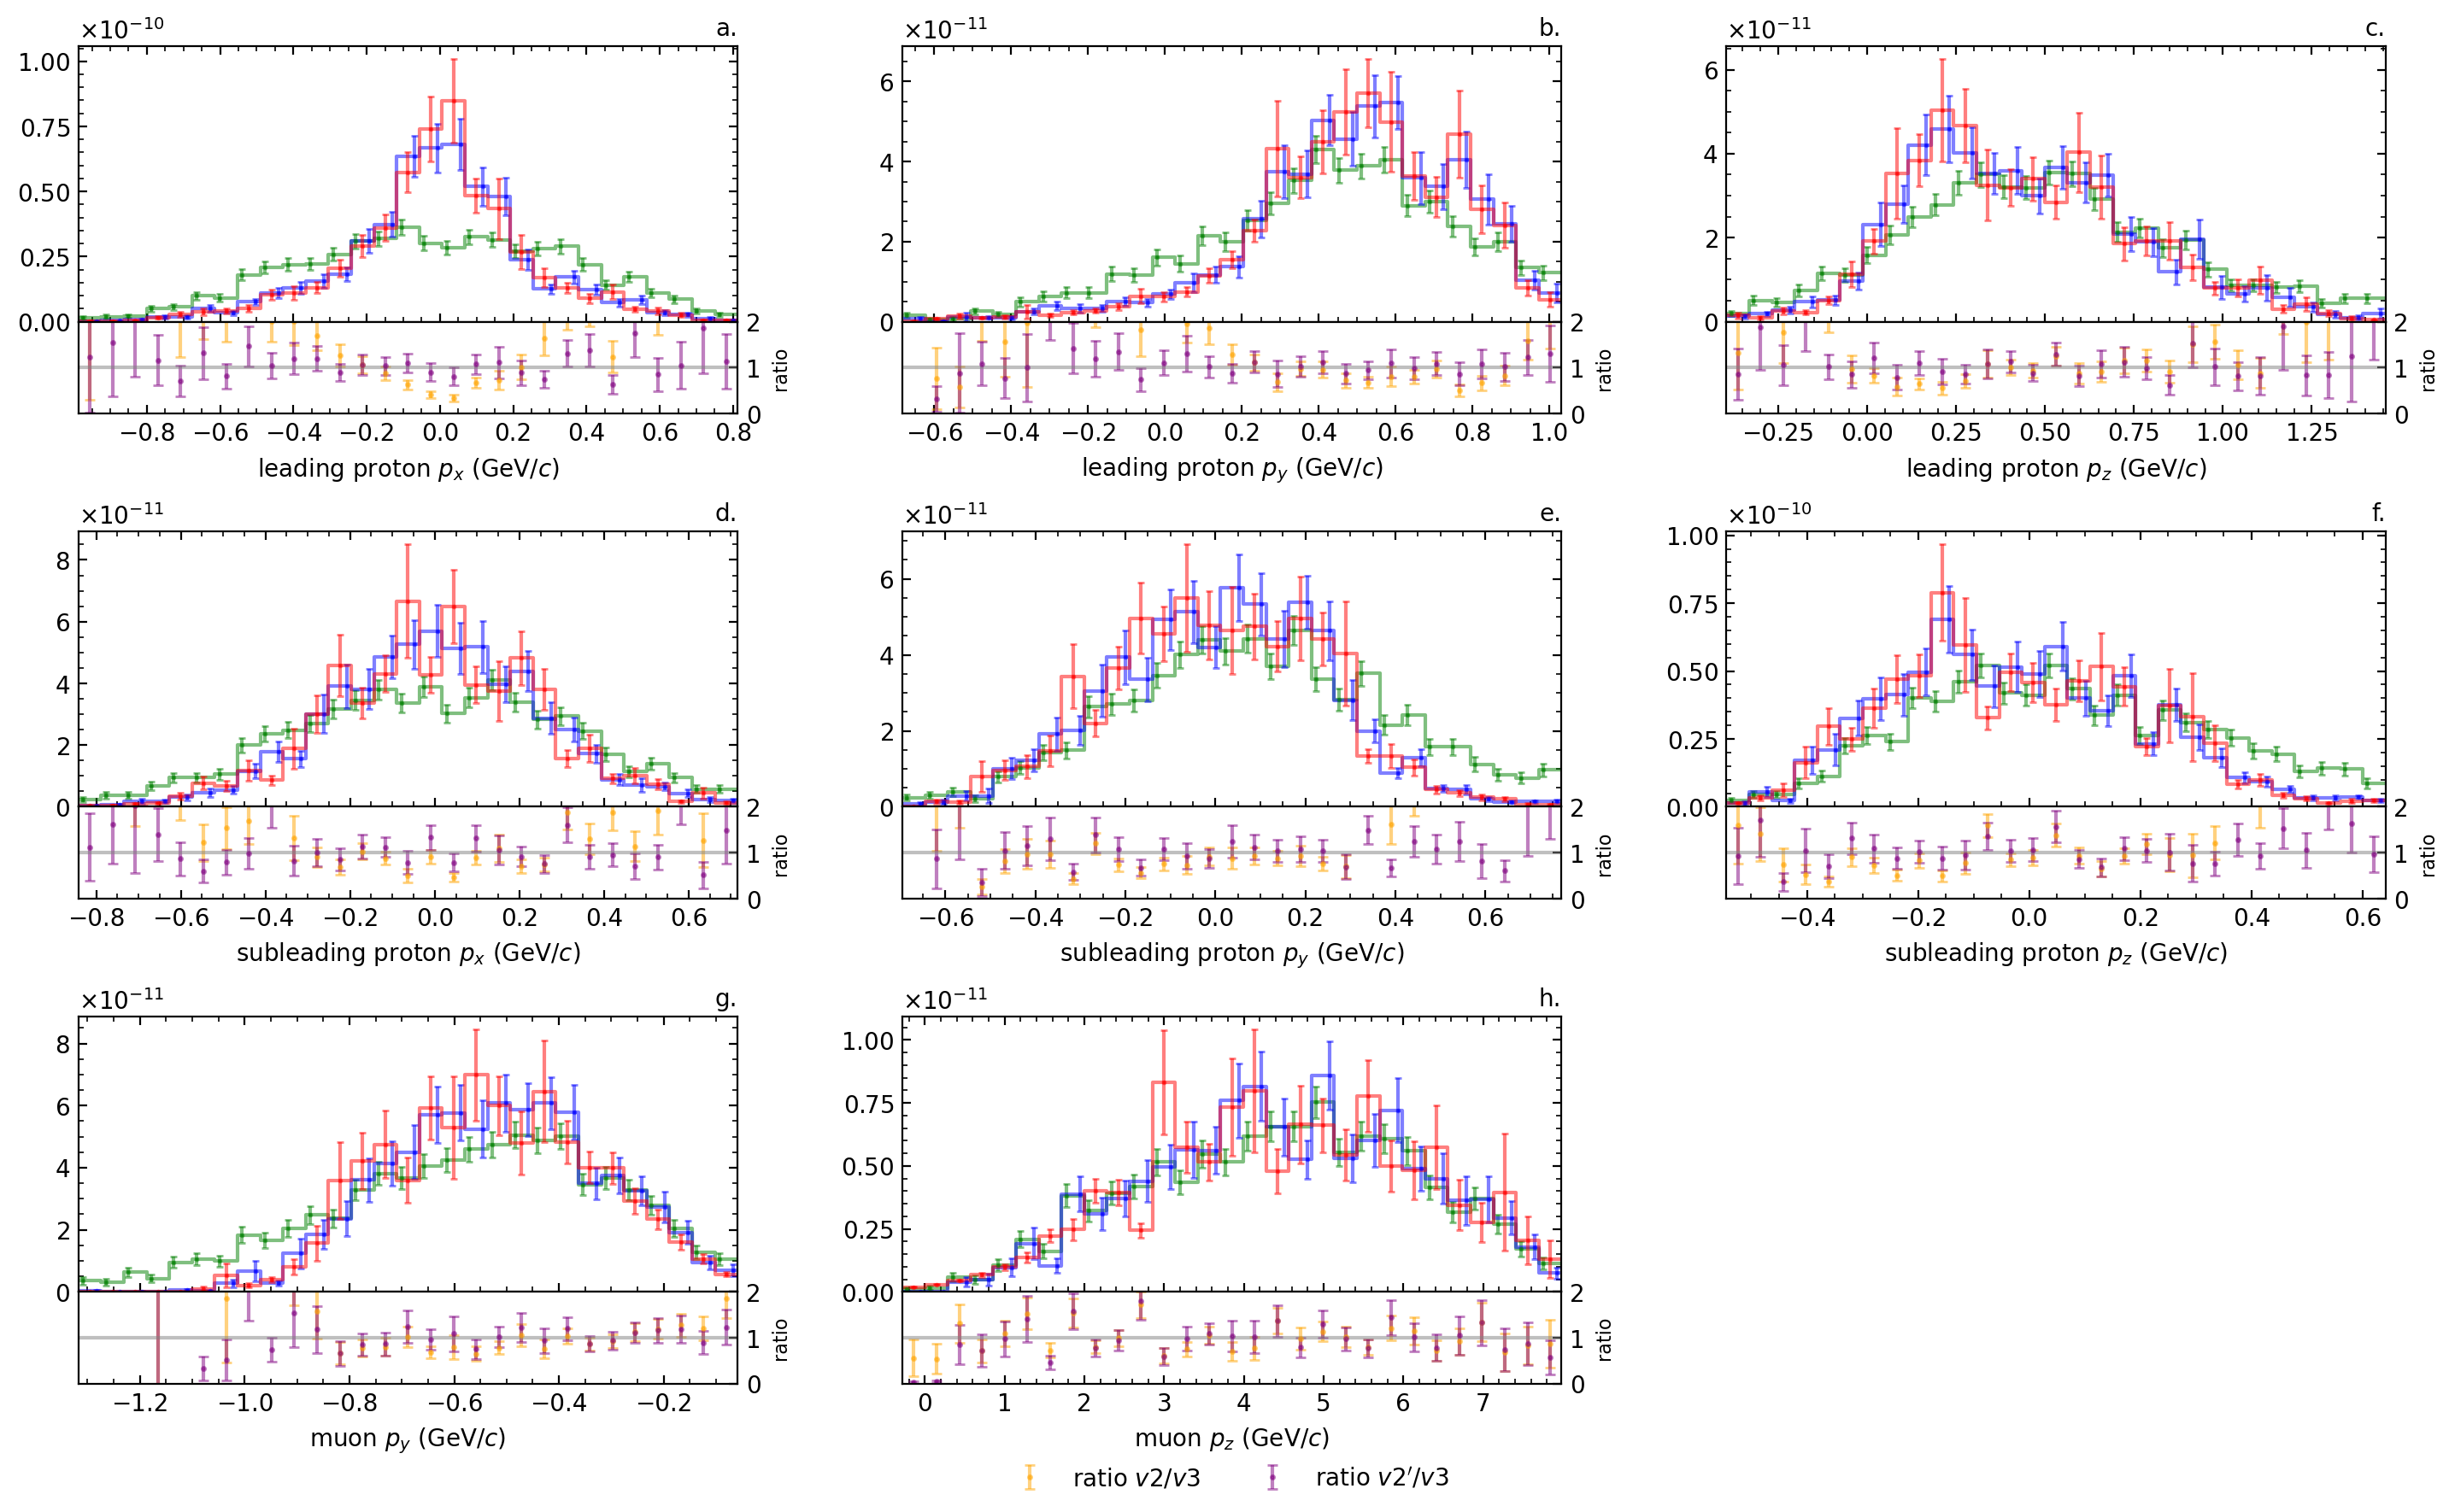

In [11]:
# predict weights and plot. weight3: from old inclusive directly to new exclusive

oldInclusive[category]['weight3'] = reweighter.predict_matched_total_weights(oldInclusive[category][reweight_variables], 
            original_weight=oldInclusive[category]['weight0'],
            target_weight=newExclusive[category]['weight']
)
oldInclusive[category]['weight'] = oldInclusive[category]['weight3']

drawing_variables=[
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    # 'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_py', 'leading_muon_pz',
    # 'init_neutrino_E',
    # 'q3', 'q0','Q2',
    # 'weight',
]

mask = oldInclusive[category]['weight3']>=0
draw_source_target_distributions_and_ratio(oldInclusive[category].loc[mask], newExclusive[category], variables=drawing_variables,
    source_weights=oldInclusive[category].loc[mask]['weight0'], 
    new_source_weights=oldInclusive[category].loc[mask]['weight3'], 
    target_weights=newExclusive[category]['weight'],
    xlabels = [particle_variable_to_latex(var) for var in drawing_variables],
    # ylabels = [diff_xsec_latex_wrt_variable(var) for var in drawing_variables],
    ylabels = ['', '', '', '', '', '', '', ''],
    # ylabels = [diff_xsec_latex_wrt_variable(var) for var in drawing_variables],
    KS_test=False,

)


Prepare post FSI pp

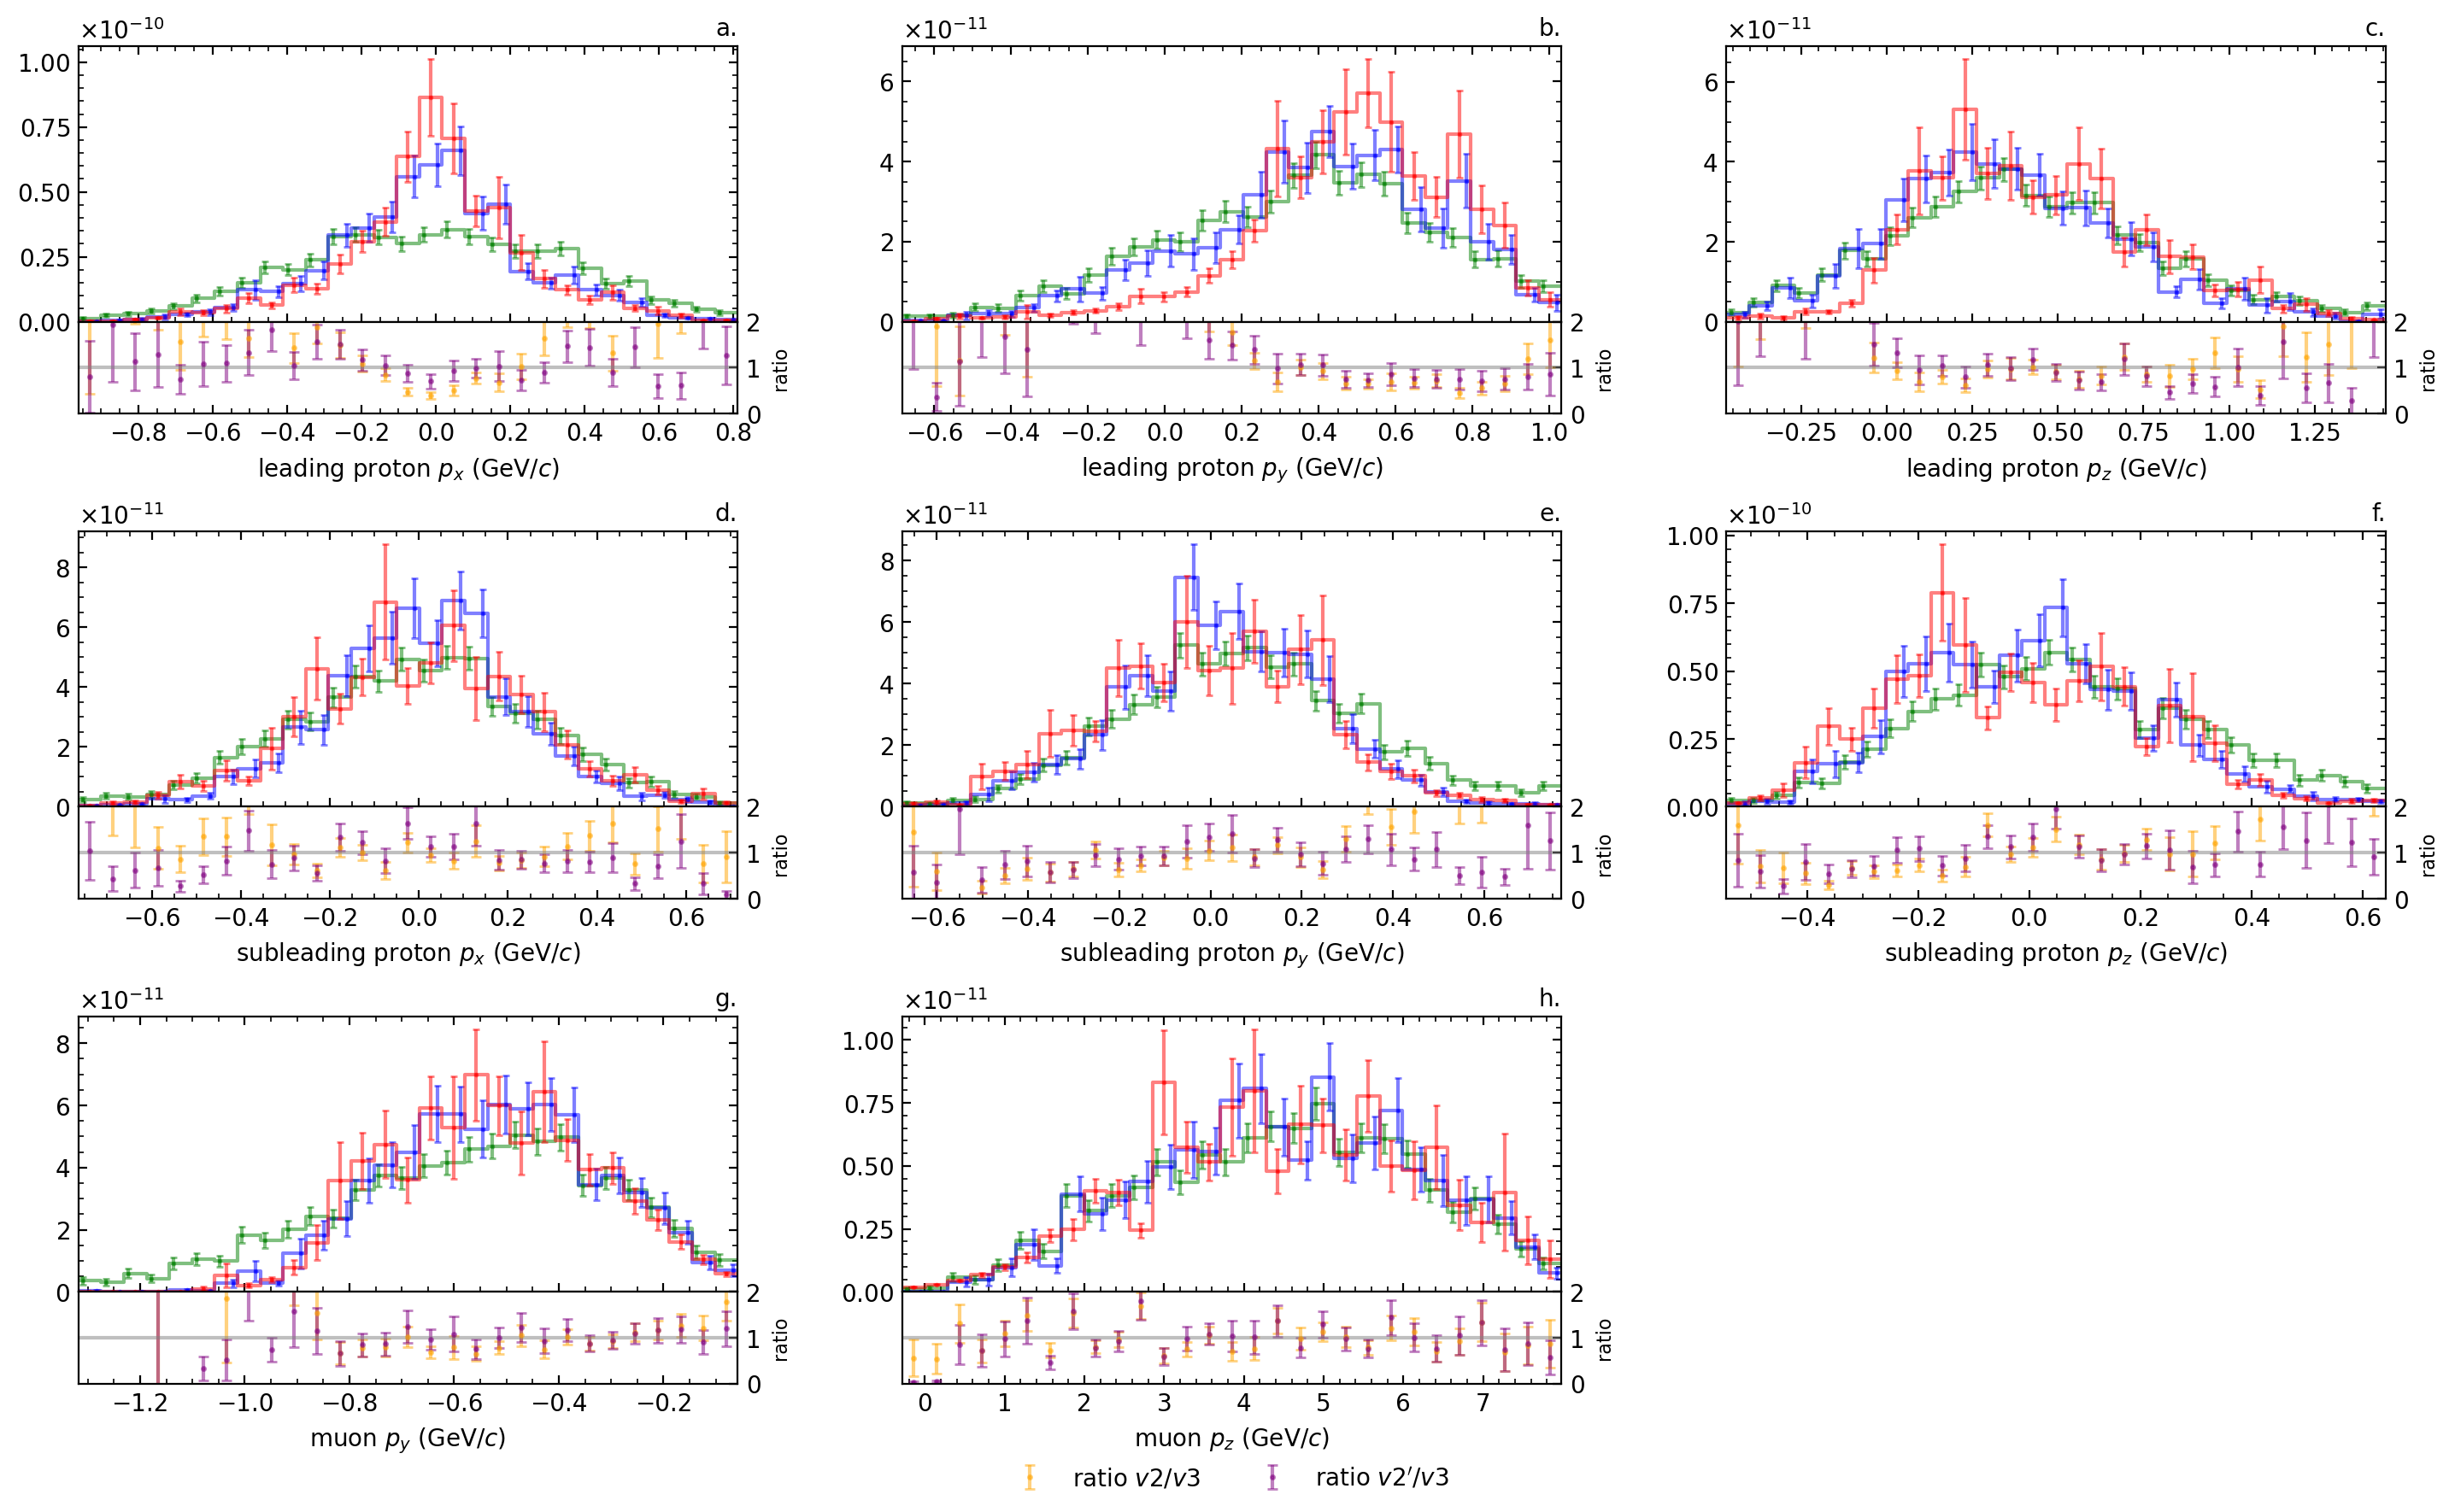

In [12]:
# prepare post FSI old inclusive dataframes and plot, pp

category = 'pp'
tree_genie = NuisanceFlatTree(f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIEv3_AR23_MINERvA_ME_FHC_numu_CH_{geniev3_seed}_NUISFLAT.root')
tree_genie._flattree_vars = tree_genie._flattree_vars[oldInclusive[category]['entry']]
variable_exprs = ['leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
                'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
                'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
                'q0', 'q3', 'Q2', 'Enu_true']
df_postFSI = create_dataframe_from_nuisance(tree_genie, variable_exprs=variable_exprs)
df_postFSI = transform_momentum_to_reaction_frame(df_postFSI,                                                          
    selector_lepton='leading_muon', particle_names=['leading_proton', 'subleading_proton'])
df_postFSI = df_postFSI.rename(columns = {'Enu_true':'init_neutrino_E'})
df_postFSI['weight0'] = oldInclusive[category]['weight0']
df_postFSI['weight3'] = oldInclusive[category]['weight3']


df_postFSI = df_postFSI.dropna()
draw_source_target_distributions_and_ratio(df_postFSI, newExclusive[category], variables=drawing_variables,
    source_weights=df_postFSI['weight0'], 
    new_source_weights=df_postFSI['weight3'], 
    target_weights=newExclusive[category]['weight'],
    xlabels = [particle_variable_to_latex(var) for var in drawing_variables],
    ylabels = ['', '', '', '', '', '', '', ''],
    # ylabels = [diff_xsec_latex_wrt_variable(var) for var in drawing_variables],
    KS_test=False,
)


Reweight and plot pn, preFSI

In [13]:
# prepare dataframes and reweight training

category = 'pn'


# reweight to new inclusive first:
# train reweighter
reweight_variables = [
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    # 'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_muon_py', 'leading_muon_pz',
    # 'init_neutrino_E'
]

reweighter = Reweighter(n_estimators=200, learning_rate=0.1, max_depth=4, min_samples_leaf=20, gb_args={'subsample': 1.0})
reweighter.fit(oldInclusive[category][reweight_variables], newExclusive[category][reweight_variables],
            original_weight=oldInclusive[category]['weight0'],
            target_weight=newExclusive[category]['weight']
)
# reweighter.save_to_pickle(f'/exp/minerva/data/users/zihaolin/BDTReweighters/saved_reweighters_pickle/Valencia/reweighter_Minerva_flux_Valencia_2p2h_newInclusive_to_newExclusive_{category}.pkl')
# # load from saved
# reweighter = Reweighter.load_from_pickle(f'/exp/minerva/data/users/zihaolin/BDTReweighters/saved_reweighters_pickle/Valencia/reweighter_Minerva_flux_Valencia_2p2h_newInclusive_to_newExclusive_{category}.pkl')


,n_estimators,200
,learning_rate,0.1
,max_depth,4
,min_samples_leaf,20
,loss_regularization,5
,gb_args,{'subsample': 1.0}


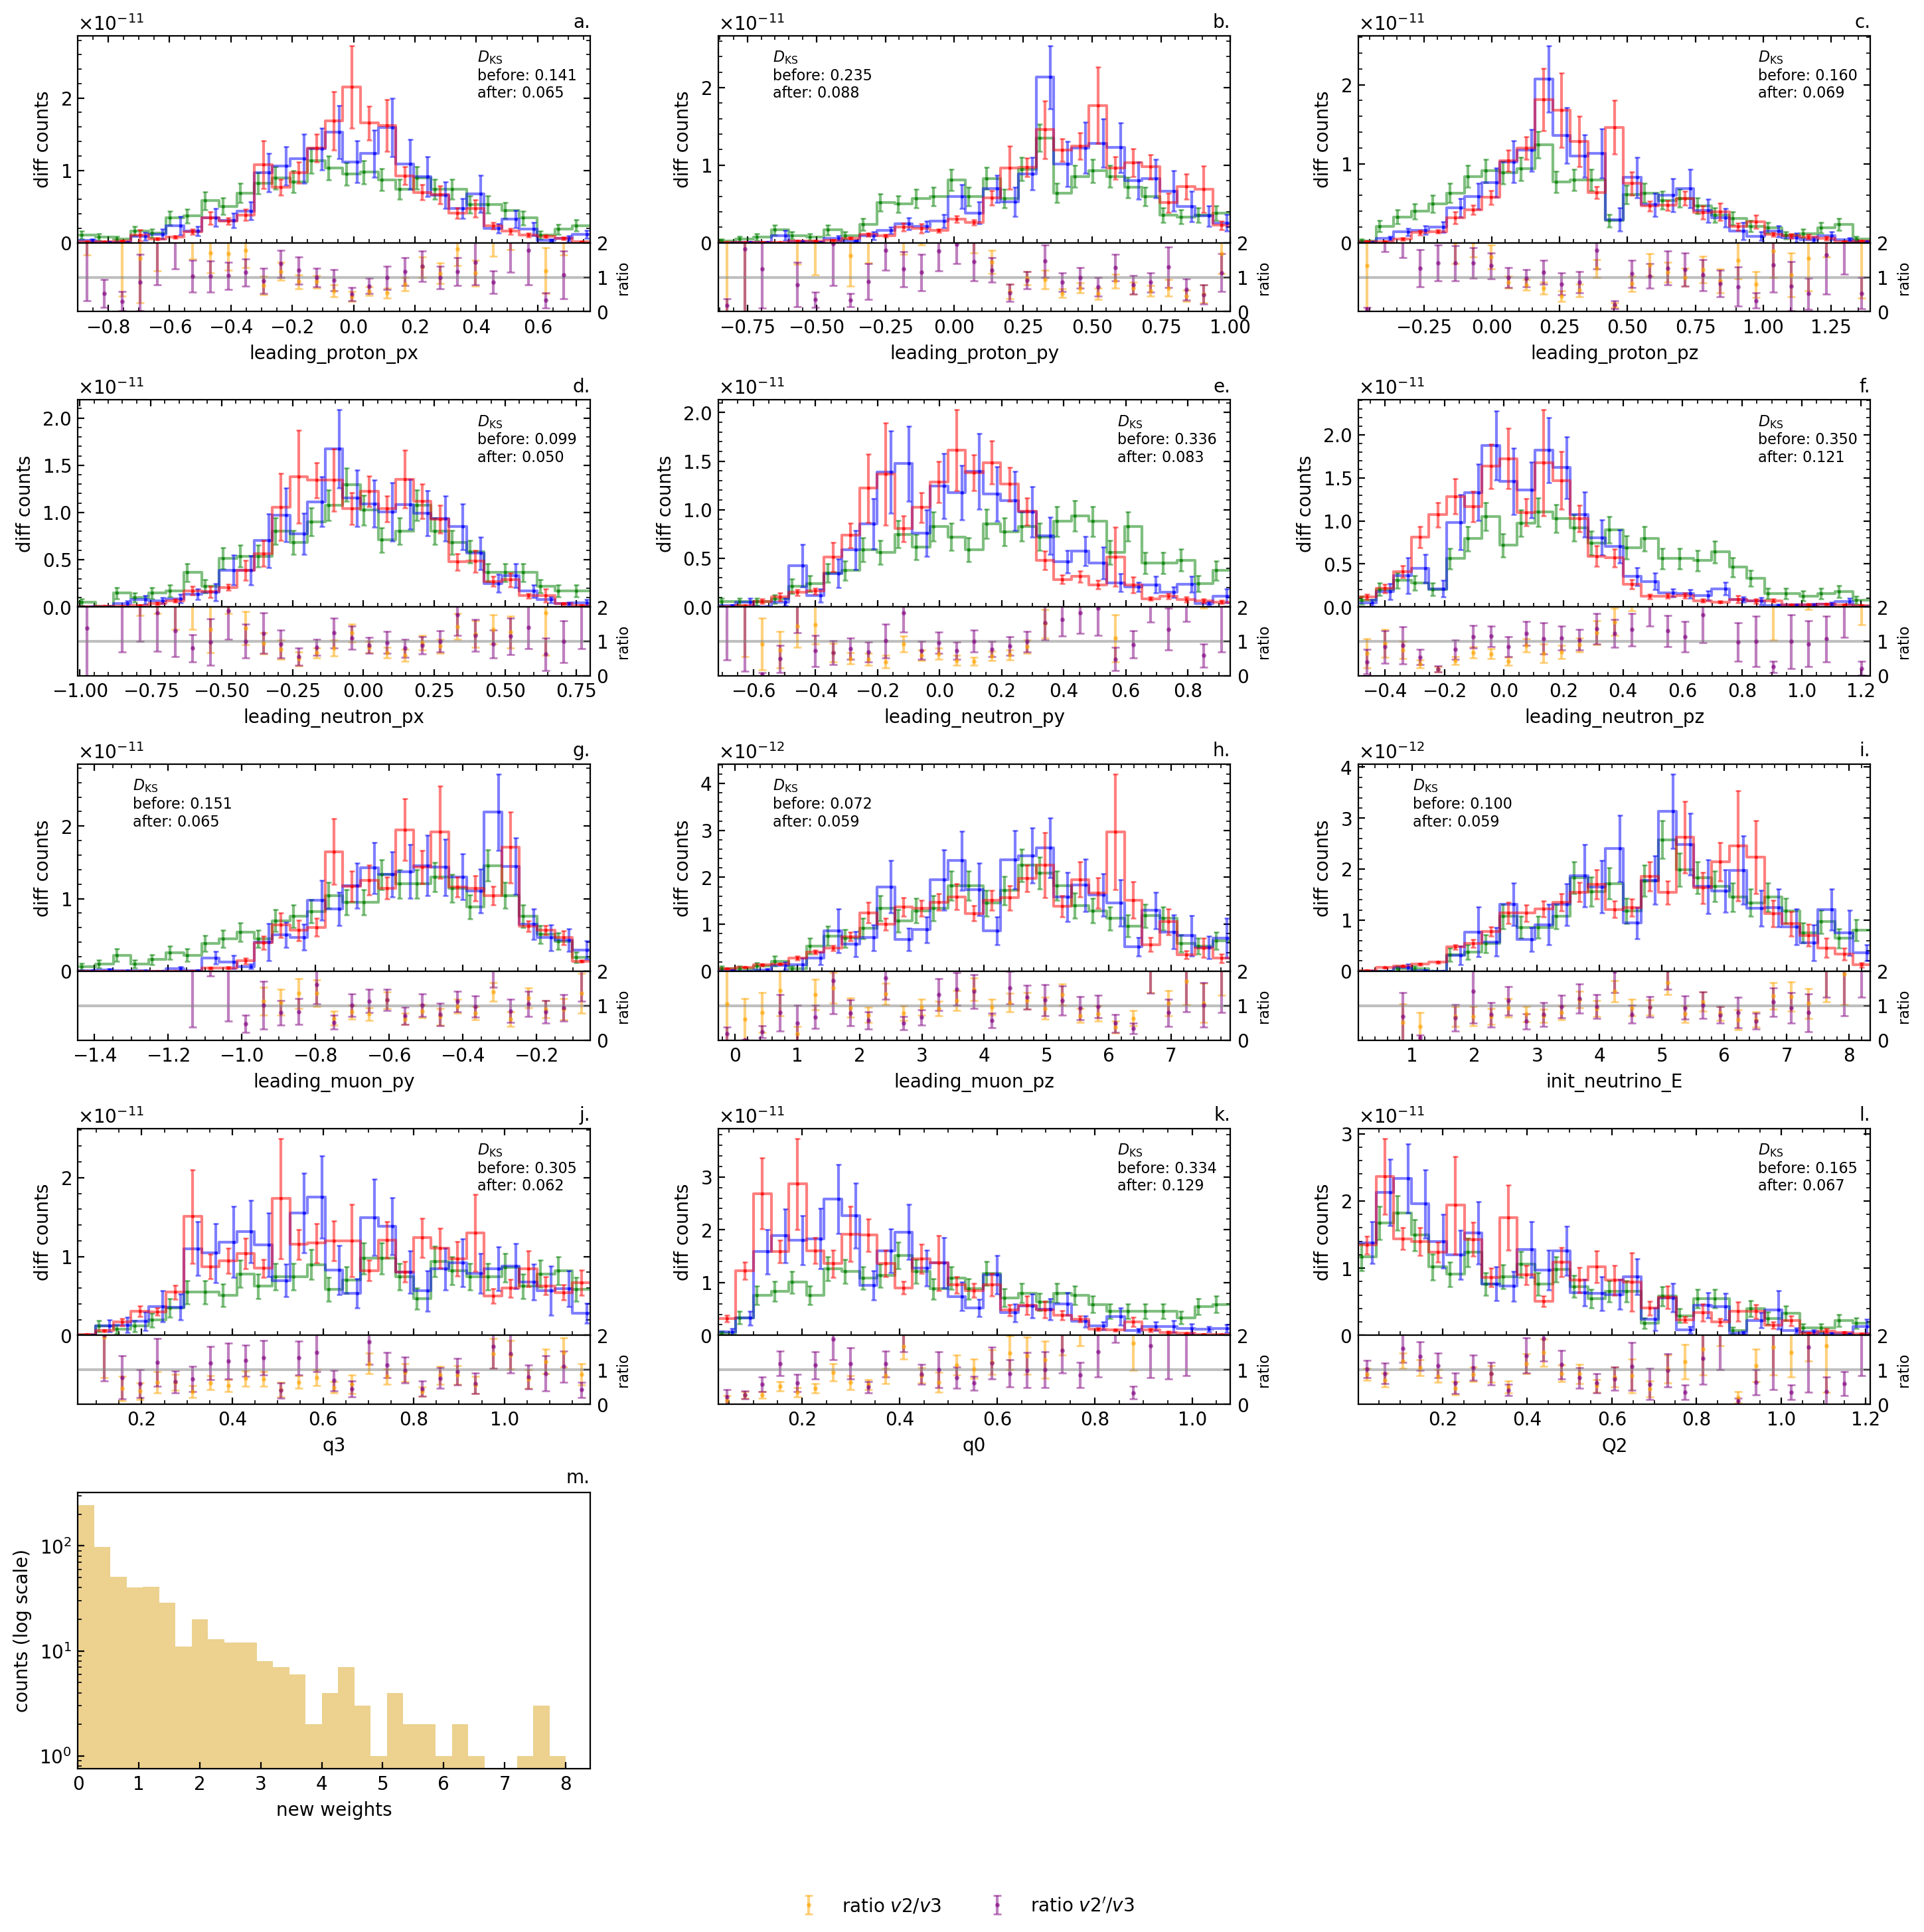

In [14]:
# predict weights and plot. weight3: from old inclusive directly to new exclusive

oldInclusive[category]['weight3'] = reweighter.predict_matched_total_weights(oldInclusive[category][reweight_variables], 
            original_weight=oldInclusive[category]['weight0'],
            target_weight=newExclusive[category]['weight']
)
oldInclusive[category]['weight'] = oldInclusive[category]['weight3']

drawing_variables=[
    'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
    # 'subleading_proton_px', 'subleading_proton_py', 'subleading_proton_pz',
    'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
    'leading_muon_py', 'leading_muon_pz',
    'init_neutrino_E',
    'q3', 'q0','Q2',
    'weight',
]

mask = oldInclusive[category]['weight3']>=0
draw_source_target_distributions_and_ratio(oldInclusive[category].loc[mask], newExclusive[category], variables=drawing_variables,
    source_weights=oldInclusive[category].loc[mask]['weight0'], 
    new_source_weights=oldInclusive[category].loc[mask]['weight3'], 
    target_weights=newExclusive[category]['weight']
)


Prepare post FSI pn

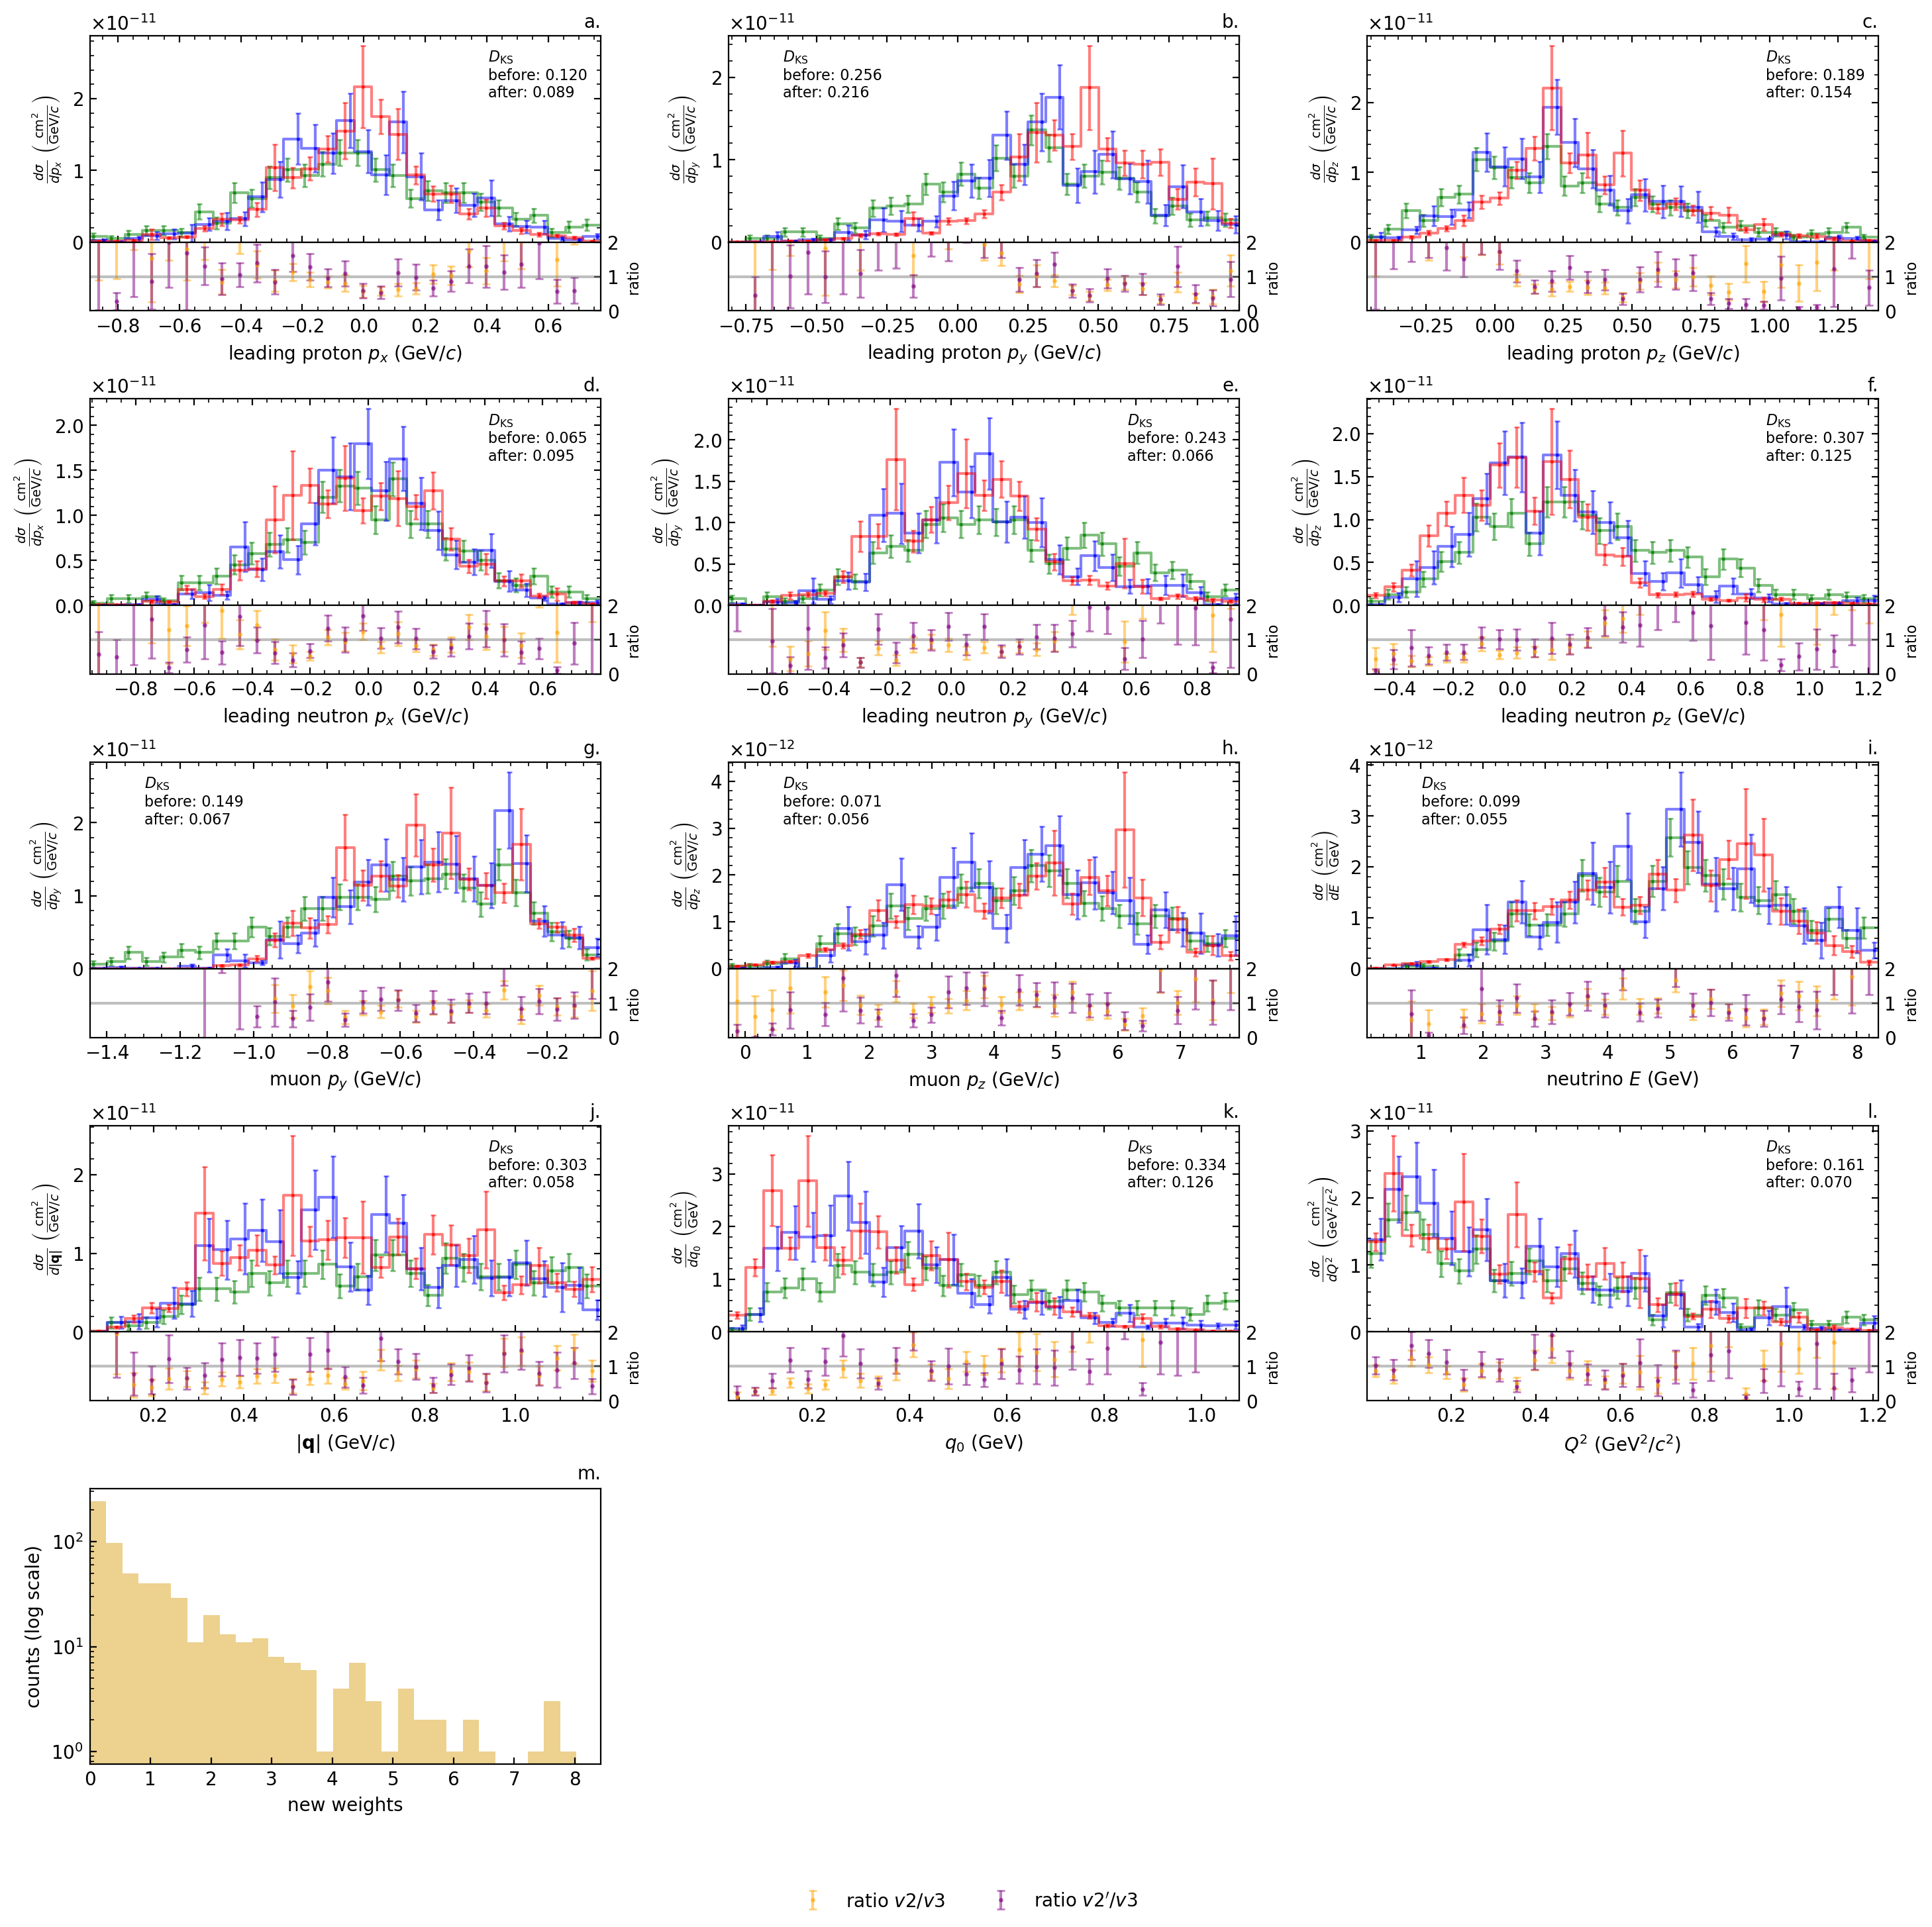

In [15]:
# prepare post FSI old inclusive dataframes and plot, pp

category = 'pn'
tree_genie = NuisanceFlatTree(f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIEv3_AR23_MINERvA_ME_FHC_numu_CH_{geniev3_seed}_NUISFLAT.root')
tree_genie._flattree_vars = tree_genie._flattree_vars[oldInclusive[category]['entry']]
variable_exprs = ['leading_muon_px', 'leading_muon_py', 'leading_muon_pz',
                'leading_proton_px', 'leading_proton_py', 'leading_proton_pz',
                'leading_neutron_px', 'leading_neutron_py', 'leading_neutron_pz',
                'q0', 'q3', 'Q2', 'Enu_true']
df_postFSI = create_dataframe_from_nuisance(tree_genie, variable_exprs=variable_exprs)
df_postFSI = transform_momentum_to_reaction_frame(df_postFSI,                                                          
    selector_lepton='leading_muon', particle_names=['leading_proton', 'leading_neutron'])
df_postFSI = df_postFSI.rename(columns = {'Enu_true':'init_neutrino_E'})
df_postFSI['weight0'] = oldInclusive[category]['weight0']
df_postFSI['weight3'] = oldInclusive[category]['weight3']

df_postFSI = df_postFSI.dropna()
draw_source_target_distributions_and_ratio(df_postFSI, newExclusive[category], variables=drawing_variables,
    source_weights=df_postFSI['weight0'], 
    new_source_weights=df_postFSI['weight3'], 
    target_weights=newExclusive[category]['weight'],
    xlabels = [particle_variable_to_latex(var) for var in drawing_variables],
    ylabels = [diff_xsec_latex_wrt_variable(var) for var in drawing_variables],
)


In [16]:
# inspect reweighter
print(type(reweighter))
print(reweighter.__dict__.keys())

print(type(reweighter.gb))
print(reweighter.gb.__dict__.keys())

print(type(reweighter.gb.estimators))
print(len(reweighter.gb.estimators))
print(type(reweighter.gb.estimators[0]))
print(reweighter.gb.estimators[0])

<class 'BDTReweight.reweighter.Reweighter'>
dict_keys(['learning_rate', 'n_estimators', 'max_depth', 'min_samples_leaf', 'gb_args', 'loss_regularization', 'n_features_', 'gb'])
<class 'hep_ml.gradientboosting.UGradientBoostingClassifier'>
dict_keys(['loss', 'n_estimators', 'learning_rate', 'subsample', 'min_samples_split', 'min_samples_leaf', 'max_features', 'max_leaf_nodes', 'max_depth', 'update_tree', 'train_features', 'random_state', 'splitter', 'classes_', 'estimators', 'scores', 'n_features', 'initial_step'])
<class 'list'>
200
<class 'list'>
[SklearnClusteringTree(max_depth=4, min_samples_leaf=20,
                      random_state=RandomState(MT19937) at 0x7FF4943A6240), array([ 0.        ,  0.        ,  0.        ,  0.        ,  1.95184438,
        0.74535157,  0.        , -0.65334471, -3.40516704,  0.        ,
        0.        , -0.83138854,  1.13119598,  0.        , -1.50632944,
       -3.47517135,  0.        ,  0.        ,  0.        , -0.20984571,
       -2.64933406,  0.  

Save weights to csv:

In [ ]:
oldInclusive['pp'][['entry','weight0','weight3']].to_csv(
    # '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors_weights_pp.csv', 
    # '/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIE_Valencia2p2h_weight/GENIE_501_NUISFLAT_w_pp.csv',
    f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIE_Valencia2p2h_weight/GENIEv3_AR23_MINERvA_ME_FHC_numu_CH_{geniev3_seed}_NUISFLAT_w_pp.root',
    index=False)
oldInclusive['pn'][['entry','weight0','weight3']].to_csv(
    # '/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors_weights_pn.csv', 
    # '/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIE_Valencia2p2h_weight/GENIE_501_NUISFLAT_w_pn.csv',
        f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIE_Valencia2p2h_weight/GENIEv3_AR23_MINERvA_ME_FHC_numu_CH_{geniev3_seed}_NUISFLAT_w_pn.root',
    index=False)

In [ ]:
# scaling up or down
# scale_2p2h = 1e-42
scale_2p2h = 5.6e-44
# scale_2p2h = 1
# scale_2p2h = 1
for category in ['pp', 'pn']:
    df = pd.read_csv(
        # f'/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors_weights_{category}.csv'
        # f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIE_Valencia2p2h_weight/GENIE_501_NUISFLAT_w_{category}.csv'
        f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIE_Valencia2p2h_weight/GENIEv3_AR23_MINERvA_ME_FHC_numu_CH_{geniev3_seed}_NUISFLAT_w_{category}.root'
    )
    # df['weight3'] = df['weight0']*df['weight3']
    df['weight0'] = scale_2p2h * df['weight0'] 
    df['weight3'] = scale_2p2h * df['weight3'] * len(df)/df['weight3'].sum()
    df.to_csv(
        # f'/exp/minerva/data/users/zihaolin/MC_outputs/Valencia/Feb23/output_NEUT_defaults_minerva.GenericVectors_weights_{category}.csv', 
        # f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIE_Valencia2p2h_weight/GENIE_501_NUISFLAT_w_{category}.csv',
        f'/exp/minerva/data/users/zihaolin/MC_outputs/GENIE/GENIE_Valencia2p2h_weight/GENIEv3_AR23_MINERvA_ME_FHC_numu_CH_{geniev3_seed}_NUISFLAT_w_{category}.root',
        index=False
    )
